### this notebook identifies 12 15x15 patches that represent a somewhat comprehensive sampling of global ocean physics

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

In [2]:
# open llc
llc = xr.open_zarr('/orcd/data/abodner/003/LLC4320/LLC4320',consolidated=False).isel(time=0, k=0)[['Eta','XC','YC']]

In [3]:
def llc_latlon_box_indices(
    LLC,
    lat_center,
    lon_center,
    degree_extent
):
    # Allow scalar or list inputs
    lat_centers = np.atleast_1d(lat_center)
    lon_centers = np.atleast_1d(lon_center)

    if len(lat_centers) != len(lon_centers):
        raise ValueError(
            "lat_center and lon_center must have the same length"
        )

    XC = LLC["XC"]
    YC = LLC["YC"]

    faces = []
    i_0 = []
    i_1 = []
    j_0 = []
    j_1 = []

    for lat_c, lon_c in zip(lat_centers, lon_centers):
        half = degree_extent / 2.0

        lat_min = lat_c - half
        lat_max = lat_c + half
        lon_min = lon_c - half
        lon_max = lon_c + half

        for face in XC.face.values:
            xc = XC.sel(face=face)
            yc = YC.sel(face=face)

            mask = (
                (yc >= lat_min) & (yc <= lat_max) &
                (xc >= lon_min) & (xc <= lon_max)
            )

            if not bool(mask.any()):
                continue

            jj, ii = np.where(mask.values)

            j_start = int(jj.min())
            j_end = int(jj.max()) + 1
            i_start = int(ii.min())
            i_end = int(ii.max()) + 1

            faces.append(int(face))
            i_0.append(i_start)
            i_1.append(i_end)
            j_0.append(j_start)
            j_1.append(j_end)

    return faces, i_0, i_1, j_0, j_1

In [6]:
faces = [7, 7, 4, 1, 4, 1, 8, 11, 7, 8]
i_0 = [2880, 3600, 0, 720, 720, 720, 2160, 2880, 2880, 3600]
i_1 = [3600, 4320, 720, 1440, 1440, 1440, 2880, 3600, 3600, 4320]
j_0 = [0, 1440, 3600, 2880, 2160, 1440, 3600, 3600, 3600, 2160]
j_1 = [720, 2160, 4320, 3600, 2880, 2160, 4320, 4320, 4320, 2880]

face_in_dist_test = [1, 10]
i_0_in_dist_tes = [2880, 2160]
i_1_in_dist_tes = [3600, 2880]
j_1_in_dist_tes = [720, 2880]
j_0_in_dist_tes = [1440, 3600]

faces_in_dist_test = face_in_dist_test
i_0_in_dist_test = i_0_in_dist_tes
i_1_in_dist_test = i_1_in_dist_tes
j_0_in_dist_test = j_0_in_dist_tes
j_1_in_dist_test = j_1_in_dist_tes

faces_test = [10, 1]
i_0_test = [2160, 3600]
i_1_test = [2880, 4320]
j_0_test = [3600, 1440]
j_1_test = [4320, 2160]

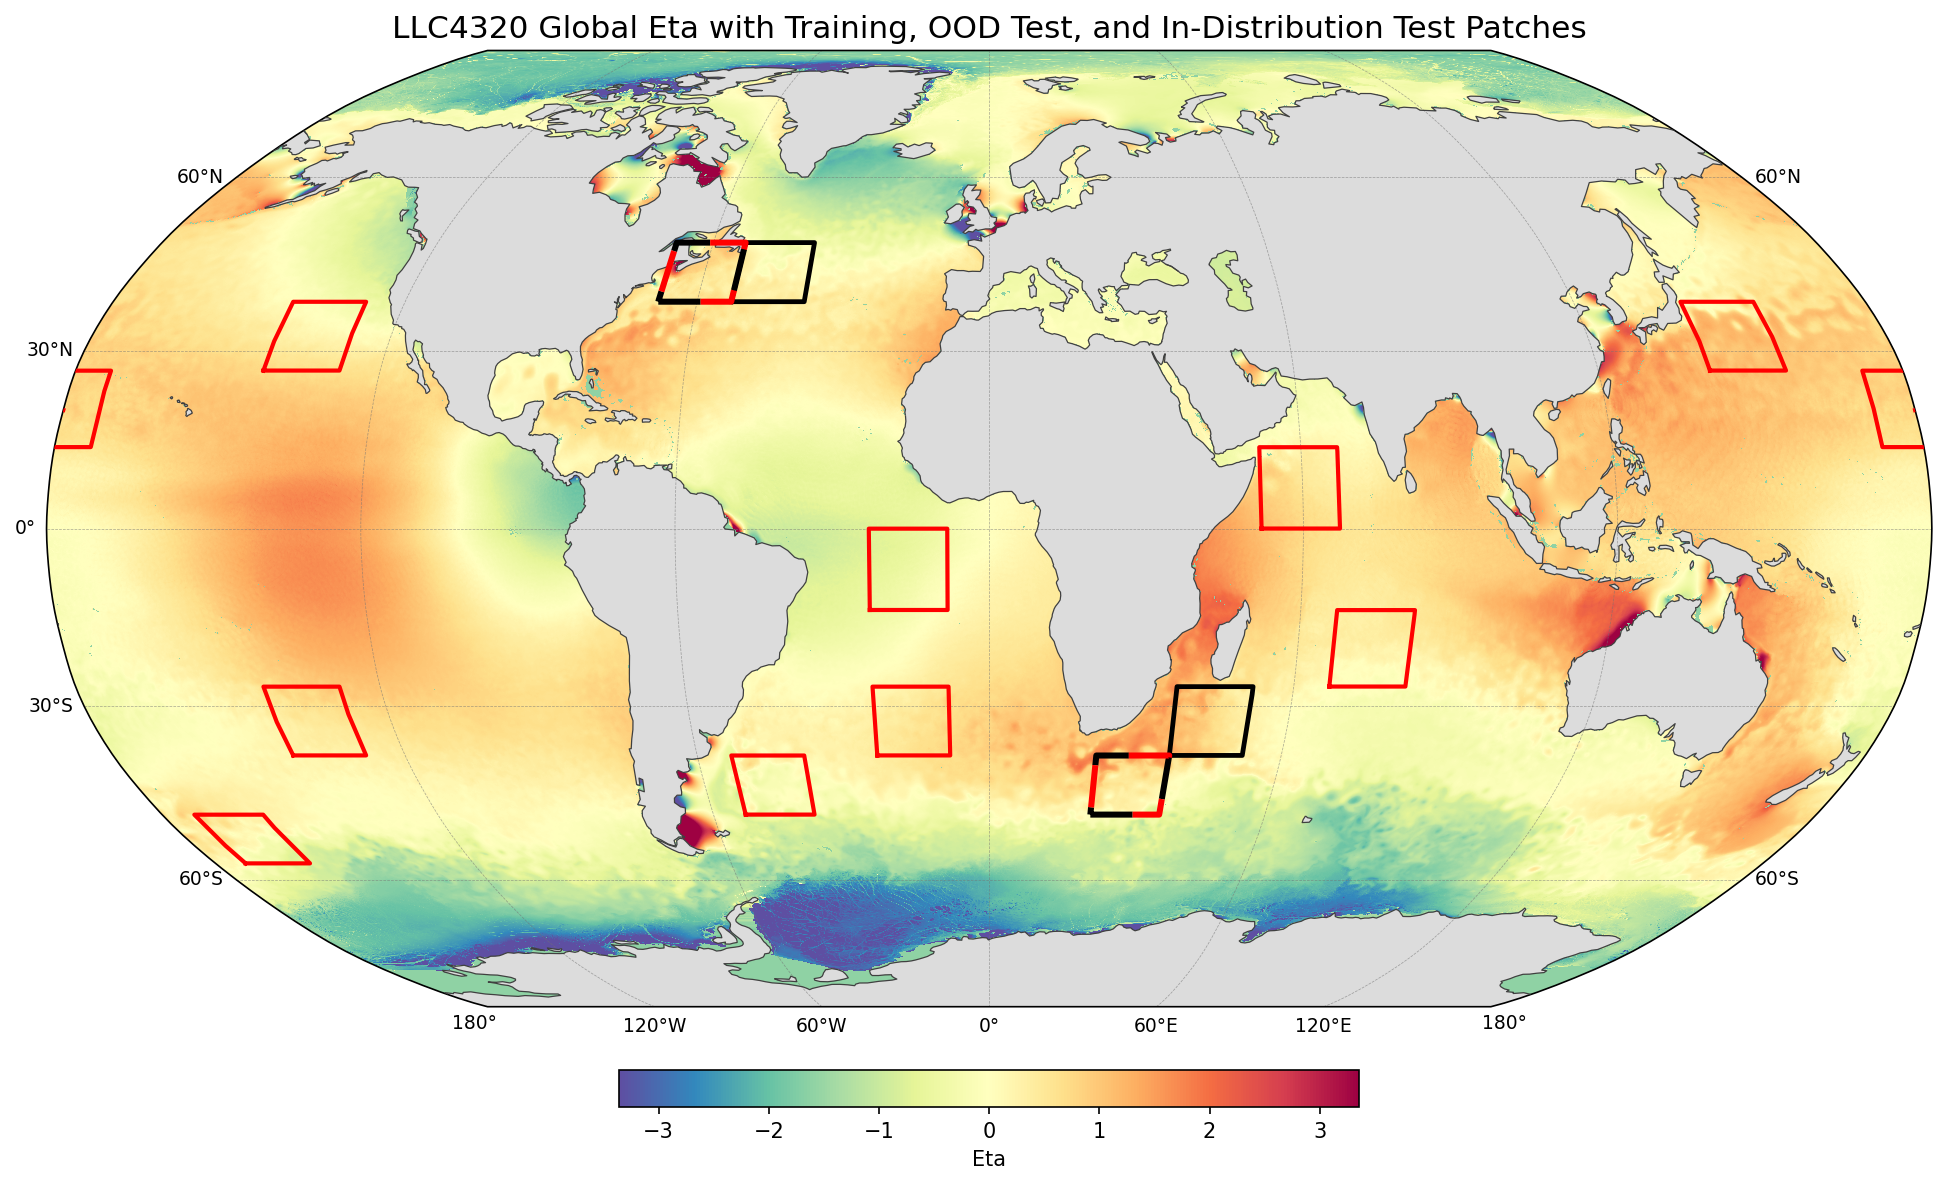

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# Box definitions
# ============================================================

# Training boxes: solid red
faces = [7, 7, 4, 1, 4, 1, 8, 11, 7, 8]
i_0 = [2880, 3600, 0, 720, 720, 720, 2160, 2880, 2880, 3600]
i_1 = [3600, 4320, 720, 1440, 1440, 1440, 2880, 3600, 3600, 4320]
j_0 = [0, 1440, 3600, 2880, 2160, 1440, 3600, 3600, 3600, 2160]
j_1 = [720, 2160, 4320, 3600, 2880, 2160, 4320, 4320, 4320, 2880]

# Out-of-distribution test boxes: solid black
faces_test = [10, 1]
i_0_test = [2160, 3600]
i_1_test = [2880, 4320]
j_0_test = [3600, 1440]
j_1_test = [4320, 2160]

# In-distribution test boxes: alternating red/black dashed
# Corrected so j_0 < j_1.
faces_in_dist_test = [1, 10]
i_0_in_dist_test = [2880, 2160]
i_1_in_dist_test = [3600, 2880]
j_0_in_dist_test = [720, 2880]
j_1_in_dist_test = [1440, 3600]


# ============================================================
# Data and color scaling
# ============================================================

plot_var = "Eta"

eta = llc[plot_var]
xc = llc["XC"]
yc = llc["YC"]

raw = eta.compute().values

valid = np.isfinite(raw) & (raw != 0.0)
vlim = float(np.nanpercentile(np.abs(raw[valid]), 98))

norm = colors.TwoSlopeNorm(
    vmin=-vlim,
    vcenter=0.0,
    vmax=vlim,
)


# ============================================================
# Figure setup
# ============================================================

proj = ccrs.Robinson()
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(15, 8), dpi=150)
ax = plt.axes(projection=proj)

ax.set_global()
ax.set_facecolor("gainsboro")

ax.add_feature(
    cfeature.LAND,
    facecolor="gainsboro",
    edgecolor="none",
    zorder=2,
)

ax.coastlines(
    linewidth=0.6,
    color="0.25",
    zorder=3,
)


# ============================================================
# Plot all LLC faces
# ============================================================

pcm = None

for face in llc.face.values:
    eta_face = eta.sel(face=face).compute().values
    lon_face = xc.sel(face=face).compute().values
    lat_face = yc.sel(face=face).compute().values

    eta_face = np.where(
        np.isfinite(eta_face) & (eta_face != 0.0),
        eta_face,
        np.nan,
    )

    pcm = ax.pcolormesh(
        lon_face,
        lat_face,
        eta_face,
        transform=data_crs,
        cmap="Spectral_r",
        norm=norm,
        shading="auto",
        rasterized=True,
        zorder=1,
    )


# ============================================================
# Box plotting helpers
# ============================================================

def plot_box(ax, lon_min, lon_max, lat_min, lat_max, **kwargs):
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        transform=data_crs,
        **kwargs,
    )


def plot_box_red_black_dashed(
    ax,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    linewidth=2.8,
    zorder=8,
    dash_len=7,
    gap_len=7,
):
    """
    Draw a red/black alternating dashed box.

    This works by plotting the same dashed box twice:
      - black with dash phase 0
      - red with dash phase shifted by one dash length
    """
    x = [lon_min, lon_max, lon_max, lon_min, lon_min]
    y = [lat_min, lat_min, lat_max, lat_max, lat_min]

    ax.plot(
        x,
        y,
        transform=data_crs,
        color="black",
        linewidth=linewidth,
        linestyle=(0, (dash_len, gap_len)),
        dash_capstyle="butt",
        solid_capstyle="butt",
        zorder=zorder,
    )

    ax.plot(
        x,
        y,
        transform=data_crs,
        color="red",
        linewidth=linewidth,
        linestyle=(dash_len, (dash_len, gap_len)),
        dash_capstyle="butt",
        solid_capstyle="butt",
        zorder=zorder + 0.1,
    )


def plot_box_dateline_safe(
    ax,
    lon_vals,
    lat_vals,
    red_black_dashed=False,
    **kwargs,
):
    """
    Plot a box from LLC lon/lat values.

    Handles boxes that cross the dateline by splitting them.
    """
    lon_vals = np.asarray(lon_vals)
    lat_vals = np.asarray(lat_vals)

    lon_vals = lon_vals[np.isfinite(lon_vals)]
    lat_vals = lat_vals[np.isfinite(lat_vals)]

    if lon_vals.size == 0 or lat_vals.size == 0:
        return

    lat_min = float(lat_vals.min())
    lat_max = float(lat_vals.max())

    lon_wrapped = ((lon_vals + 180.0) % 360.0) - 180.0
    lon_360 = (lon_vals + 360.0) % 360.0

    raw_min = float(lon_wrapped.min())
    raw_max = float(lon_wrapped.max())
    raw_span = raw_max - raw_min

    span_360 = float(lon_360.max() - lon_360.min())

    def draw_one(lon_min, lon_max):
        if red_black_dashed:
            plot_box_red_black_dashed(
                ax,
                lon_min,
                lon_max,
                lat_min,
                lat_max,
                linewidth=kwargs.get("linewidth", 2.8),
                zorder=kwargs.get("zorder", 8),
                dash_len=kwargs.get("dash_len", 7),
                gap_len=kwargs.get("gap_len", 7),
            )
        else:
            plot_box(
                ax,
                lon_min,
                lon_max,
                lat_min,
                lat_max,
                **kwargs,
            )

    if raw_span <= 180:
        draw_one(raw_min, raw_max)

    elif span_360 <= 180:
        lon_min = ((float(lon_360.min()) + 180.0) % 360.0) - 180.0
        lon_max = ((float(lon_360.max()) + 180.0) % 360.0) - 180.0

        if lon_min <= lon_max:
            draw_one(lon_min, lon_max)
        else:
            draw_one(lon_min, 180.0)
            draw_one(-180.0, lon_max)

    else:
        print("Skipping pathological dateline/pole-wrapping box.")


def draw_patch_boxes(
    ax,
    faces_in,
    i0_in,
    i1_in,
    j0_in,
    j1_in,
    color=None,
    linewidth=2.0,
    zorder=5,
    red_black_dashed=False,
    dash_len=7,
    gap_len=7,
):
    """
    Draw patch boxes from LLC face/i/j bounds.

    The helper sorts i and j bounds so accidentally reversed inputs
    do not produce empty slices.
    """
    for n, face in enumerate(faces_in):
        i_start = min(i0_in[n], i1_in[n])
        i_end = max(i0_in[n], i1_in[n])
        j_start = min(j0_in[n], j1_in[n])
        j_end = max(j0_in[n], j1_in[n])

        lon_box = xc.isel(
            face=face,
            j=slice(j_start, j_end),
            i=slice(i_start, i_end),
        ).compute().values

        lat_box = yc.isel(
            face=face,
            j=slice(j_start, j_end),
            i=slice(i_start, i_end),
        ).compute().values

        if lon_box.size == 0 or lat_box.size == 0:
            print(
                f"Skipping empty box n={n}, face={face}, "
                f"i={i_start}:{i_end}, j={j_start}:{j_end}"
            )
            continue

        if red_black_dashed:
            plot_box_dateline_safe(
                ax,
                lon_box.ravel(),
                lat_box.ravel(),
                red_black_dashed=True,
                linewidth=linewidth,
                zorder=zorder,
                dash_len=dash_len,
                gap_len=gap_len,
            )
        else:
            plot_box_dateline_safe(
                ax,
                lon_box.ravel(),
                lat_box.ravel(),
                color=color,
                linewidth=linewidth,
                zorder=zorder,
            )


# ============================================================
# Draw boxes
# ============================================================

# Training boxes: solid red
draw_patch_boxes(
    ax,
    faces,
    i_0,
    i_1,
    j_0,
    j_1,
    color="red",
    linewidth=2.0,
    zorder=5,
)

# OOD test boxes: solid black
draw_patch_boxes(
    ax,
    faces_test,
    i_0_test,
    i_1_test,
    j_0_test,
    j_1_test,
    color="black",
    linewidth=2.3,
    zorder=6,
)

# In-distribution test boxes: alternating red/black dashed
draw_patch_boxes(
    ax,
    faces_in_dist_test,
    i_0_in_dist_test,
    i_1_in_dist_test,
    j_0_in_dist_test,
    j_1_in_dist_test,
    linewidth=2.9,
    zorder=8,
    red_black_dashed=True,
    dash_len=7,
    gap_len=7,
)


# ============================================================
# Latitude / longitude ticks
# ============================================================

gl = ax.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.35,
    color="0.45",
    alpha=0.6,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}


# ============================================================
# Bottom colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    shrink=0.55,
    fraction=0.035,
)

cbar.set_label("Eta")


# ============================================================
# Title and show
# ============================================================

ax.set_title(
    "LLC4320 Global Eta with Training, OOD Test, and In-Distribution Test Patches",
    fontsize=15,
)

plt.tight_layout()
plt.show()

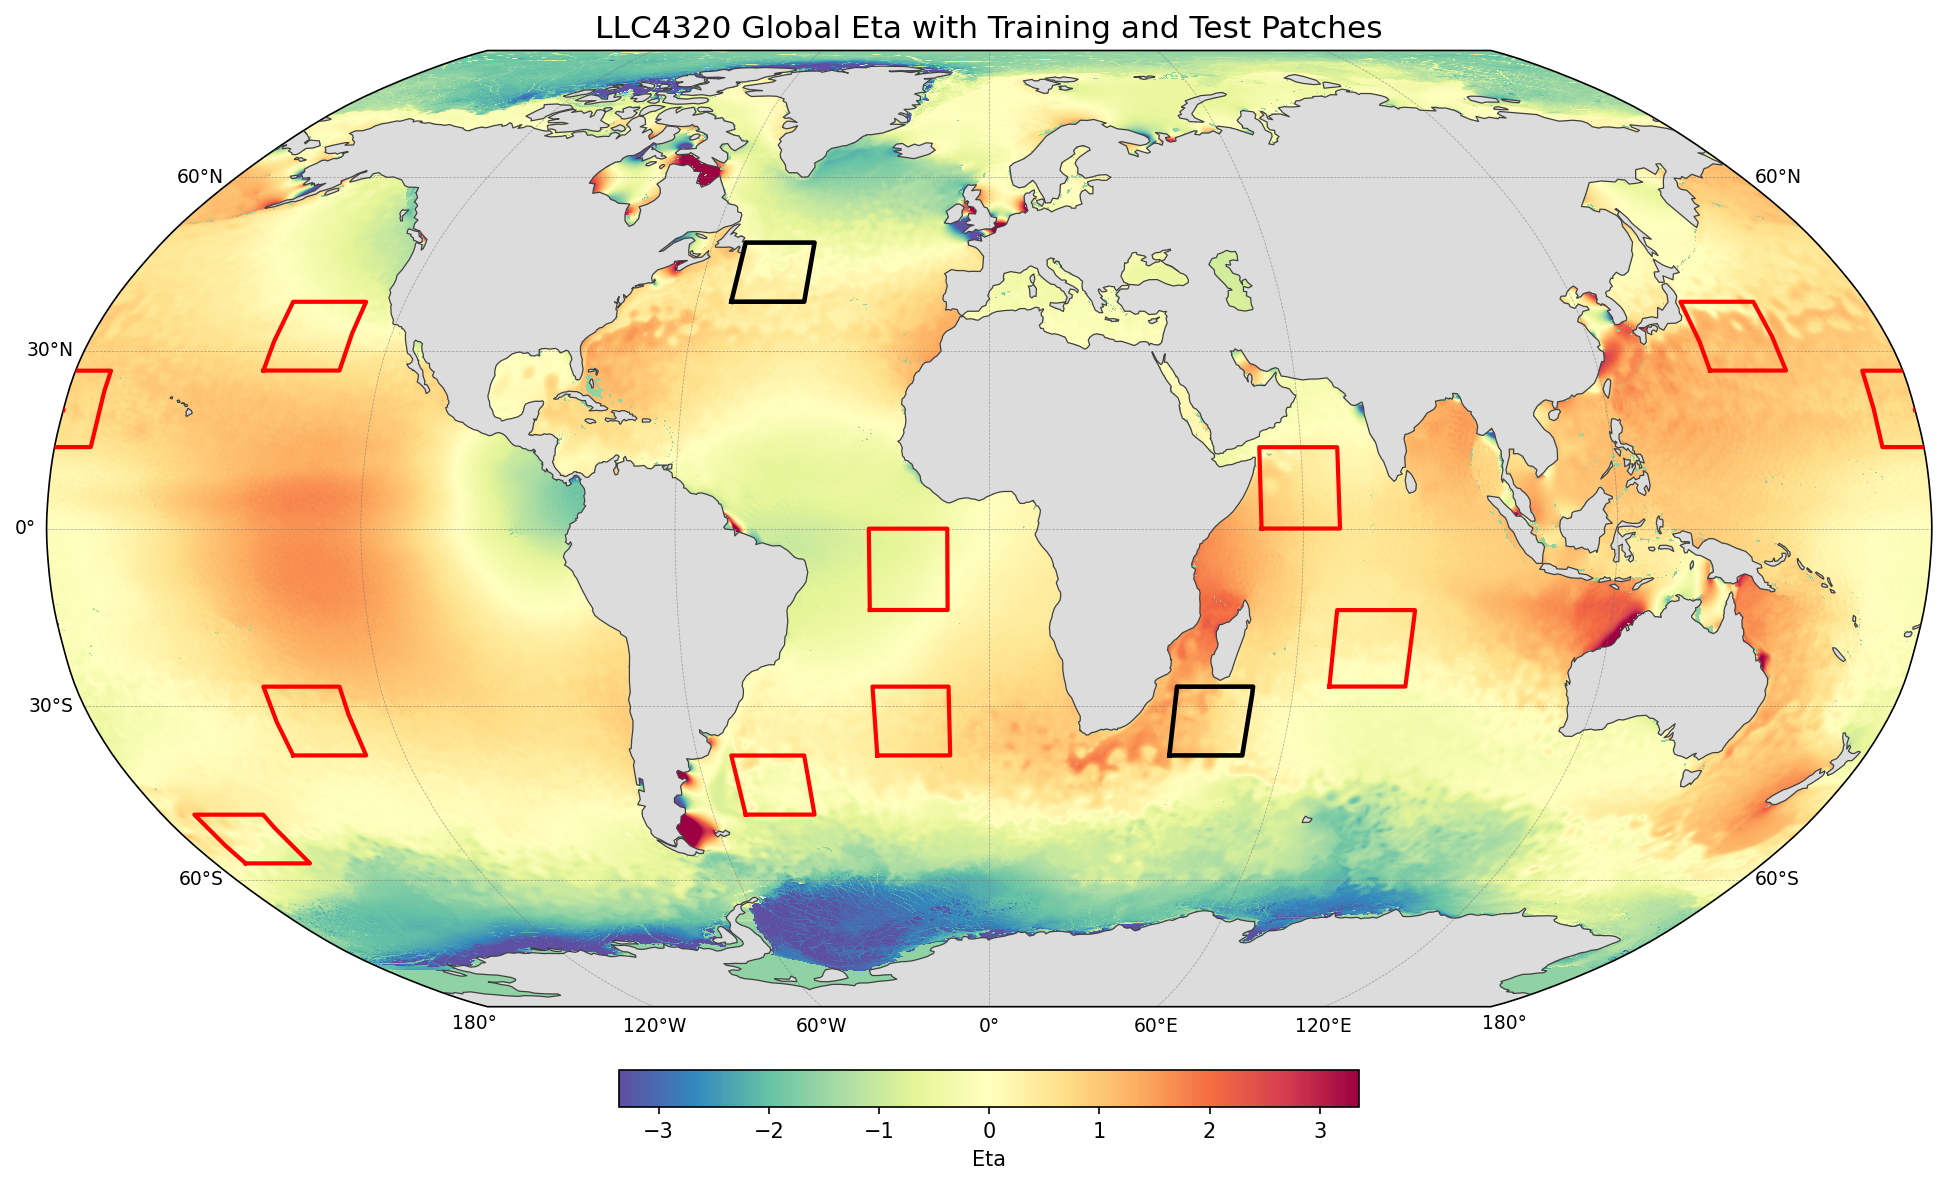

In [7]:
plot_var = "Eta"
# ----------------------------
# Datplot_var = "Eta"

# ----------------------------
# Data and color scaling
# ----------------------------
eta = llc[plot_var]
xc = llc["XC"]
yc = llc["YC"]

raw = eta.compute().values

valid = np.isfinite(raw) & (raw != 0.0)
vlim = float(np.nanpercentile(np.abs(raw[valid]), 98))

norm = colors.TwoSlopeNorm(
    vmin=-vlim,
    vcenter=0.0,
    vmax=vlim
)

# ----------------------------
# Figure setup
# ----------------------------
proj = ccrs.Robinson()
data_crs = ccrs.PlateCarree()

fig = plt.figure(figsize=(15, 8), dpi=150)
ax = plt.axes(projection=proj)

ax.set_global()
ax.set_facecolor("gainsboro")

ax.add_feature(
    cfeature.LAND,
    facecolor="gainsboro",
    edgecolor="none",
    zorder=2
)

ax.coastlines(
    linewidth=0.6,
    color="0.25",
    zorder=3
)

# ----------------------------
# Plot all LLC faces
# ----------------------------
pcm = None

for face in llc.face.values:
    eta_face = eta.sel(face=face).compute().values
    lon_face = xc.sel(face=face).compute().values
    lat_face = yc.sel(face=face).compute().values

    eta_face = np.where(
        np.isfinite(eta_face) & (eta_face != 0.0),
        eta_face,
        np.nan
    )

    pcm = ax.pcolormesh(
        lon_face,
        lat_face,
        eta_face,
        transform=data_crs,
        cmap="Spectral_r",
        norm=norm,
        shading="auto",
        rasterized=True,
        zorder=1
    )

# ----------------------------
# Box plotting helpers
# ----------------------------
def plot_box(ax, lon_min, lon_max, lat_min, lat_max, **kwargs):
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        transform=data_crs,
        **kwargs
    )


def plot_box_alternating_red_black(
    ax,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    linewidth=2.4,
    zorder=7
):
    """
    Draw one box with alternating red/black dashed segments by overlaying
    two dashed lines with opposite dash phase.
    """
    x = [lon_min, lon_max, lon_max, lon_min, lon_min]
    y = [lat_min, lat_min, lat_max, lat_max, lat_min]

    ax.plot(
        x,
        y,
        transform=data_crs,
        color="black",
        linewidth=linewidth,
        linestyle=(0, (7, 7)),
        solid_capstyle="butt",
        dash_capstyle="butt",
        zorder=zorder
    )

    ax.plot(
        x,
        y,
        transform=data_crs,
        color="red",
        linewidth=linewidth,
        linestyle=(7, (7, 7)),
        solid_capstyle="butt",
        dash_capstyle="butt",
        zorder=zorder + 0.1
    )


def plot_box_dateline_safe(
    ax,
    lon_vals,
    lat_vals,
    alternating_red_black=False,
    **kwargs
):
    lon_vals = np.asarray(lon_vals)
    lat_vals = np.asarray(lat_vals)

    lon_vals = lon_vals[np.isfinite(lon_vals)]
    lat_vals = lat_vals[np.isfinite(lat_vals)]

    if lon_vals.size == 0 or lat_vals.size == 0:
        return

    lat_min = float(lat_vals.min())
    lat_max = float(lat_vals.max())

    lon_wrapped = ((lon_vals + 180.0) % 360.0) - 180.0
    lon_360 = (lon_vals + 360.0) % 360.0

    raw_min = float(lon_wrapped.min())
    raw_max = float(lon_wrapped.max())
    raw_span = raw_max - raw_min

    span_360 = float(lon_360.max() - lon_360.min())

    def draw(lon_min, lon_max):
        if alternating_red_black:
            plot_box_alternating_red_black(
                ax,
                lon_min,
                lon_max,
                lat_min,
                lat_max,
                linewidth=kwargs.get("linewidth", 2.4),
                zorder=kwargs.get("zorder", 7)
            )
        else:
            plot_box(
                ax,
                lon_min,
                lon_max,
                lat_min,
                lat_max,
                **kwargs
            )

    if raw_span <= 180:
        draw(raw_min, raw_max)

    elif span_360 <= 180:
        lon_min = ((float(lon_360.min()) + 180.0) % 360.0) - 180.0
        lon_max = ((float(lon_360.max()) + 180.0) % 360.0) - 180.0

        if lon_min <= lon_max:
            draw(lon_min, lon_max)
        else:
            draw(lon_min, 180.0)
            draw(-180.0, lon_max)


def draw_patch_boxes(
    ax,
    faces_in,
    i0_in,
    i1_in,
    j0_in,
    j1_in,
    color=None,
    linewidth=2.0,
    zorder=5,
    alternating_red_black=False
):
    for n, face in enumerate(faces_in):
        lon_box = xc.isel(
            face=face,
            j=slice(j0_in[n], j1_in[n]),
            i=slice(i0_in[n], i1_in[n])
        ).compute().values

        lat_box = yc.isel(
            face=face,
            j=slice(j0_in[n], j1_in[n]),
            i=slice(i0_in[n], i1_in[n])
        ).compute().values

        if alternating_red_black:
            plot_box_dateline_safe(
                ax,
                lon_box.ravel(),
                lat_box.ravel(),
                alternating_red_black=True,
                linewidth=linewidth,
                zorder=zorder
            )
        else:
            plot_box_dateline_safe(
                ax,
                lon_box.ravel(),
                lat_box.ravel(),
                color=color,
                linewidth=linewidth,
                zorder=zorder
            )

# ----------------------------
# Draw red training boxes
# ----------------------------
draw_patch_boxes(
    ax,
    faces,
    i_0,
    i_1,
    j_0,
    j_1,
    color="red",
    linewidth=2.0,
    zorder=5
)

# ----------------------------
# Draw black test boxes
# ----------------------------
draw_patch_boxes(
    ax,
    faces_test,
    i_0_test,
    i_1_test,
    j_0_test,
    j_1_test,
    color="black",
    linewidth=2.2,
    zorder=6
)

# ----------------------------
# Draw red/black dashed in-distribution test boxes
# ----------------------------
draw_patch_boxes(
    ax,
    face_in_dist_test,
    i_0_in_dist_tes,
    i_1_in_dist_tes,
    j_0_in_dist_tes,
    j_1_in_dist_tes,
    linewidth=2.6,
    zorder=7,
    alternating_red_black=True
)

# ----------------------------
# Latitude / longitude ticks
# ----------------------------
gl = ax.gridlines(
    crs=data_crs,
    draw_labels=True,
    linewidth=0.35,
    color="0.45",
    alpha=0.6,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-90, 91, 30))

gl.xlabel_style = {"size": 9}
gl.ylabel_style = {"size": 9}

# ----------------------------
# Bottom colorbar
# ----------------------------
cbar = fig.colorbar(
    pcm,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    shrink=0.55,
    fraction=0.035
)

cbar.set_label("Eta")

# ----------------------------
# Title
# ----------------------------
ax.set_title(
    "LLC4320 Global Eta with Training and Test Patches",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [4]:
# extract 12 patch i,j extents and faces
# 1. Agulhas Current (-55,-40) (20,35) 
# 2. Gulf Stream (30,45) (-60,-45)
# 3. Kuroshio Extension (25,40) (145,160)
# 4. North Pacific (10,25) (-180,-165)
# 5. Arabian Sea (0,15) (55,70)
# 6. Equatorial Atlantic (-8,8) (-30,-15)
# 7. Indian Ocean (-25,-10) (70,85)
# 8. South Atlantic (-30,-15) (-25,-10)
# 9. South Pacific (-45,-30) (-140,-125)
# 10. Malvinas Current (-55,-40) (-60,-45)
# 11. California Current (30,45) (-140,-125)
# 12. Southern Ocean, New Zealand (-60,-45) (-175,-160)

faces = [1]
i_0 = [2880]
i_1 = [3600]
j_0 = [720]
j_1 = [1440]

lat_centers = [
    37.5,   # Gulf Stream
    32.5,   # Kuroshio Extension
    17.5,   # North Pacific
    7.5,    # Arabian Sea
    0.0,    # Equatorial Atlantic
    -17.5,  # Indian Ocean
    -22.5,  # South Atlantic
    -37.5,  # South Pacific
    -47.5,  # Malvinas Current
    37.5,   # California Current
    -52.5   # Southern Ocean, New Zealand
]

lon_centers = [
    -52.5,   # Gulf Stream
    152.5,   # Kuroshio Extension
    -172.5,  # North Pacific
    62.5,    # Arabian Sea
    -22.5,   # Equatorial Atlantic
    77.5,    # Indian Ocean
    -17.5,   # South Atlantic
    -132.5,  # South Pacific
    -52.5,   # Malvinas Current
    -132.5,  # California Current
    -167.5   # Southern Ocean, New Zealand
]

faces, i_0, i_1, j_0, j_1 = llc_latlon_box_indices(
    llc,
    lat_center=lat_centers,
    lon_center=lon_centers,
    degree_extent=15.0
)


for face, i0, i1, j0, j1 in zip(faces, i_0, i_1, j_0, j_1):
    patch = llc.sel(face=face, i=slice(i0, i1), j=slice(j0, j1))

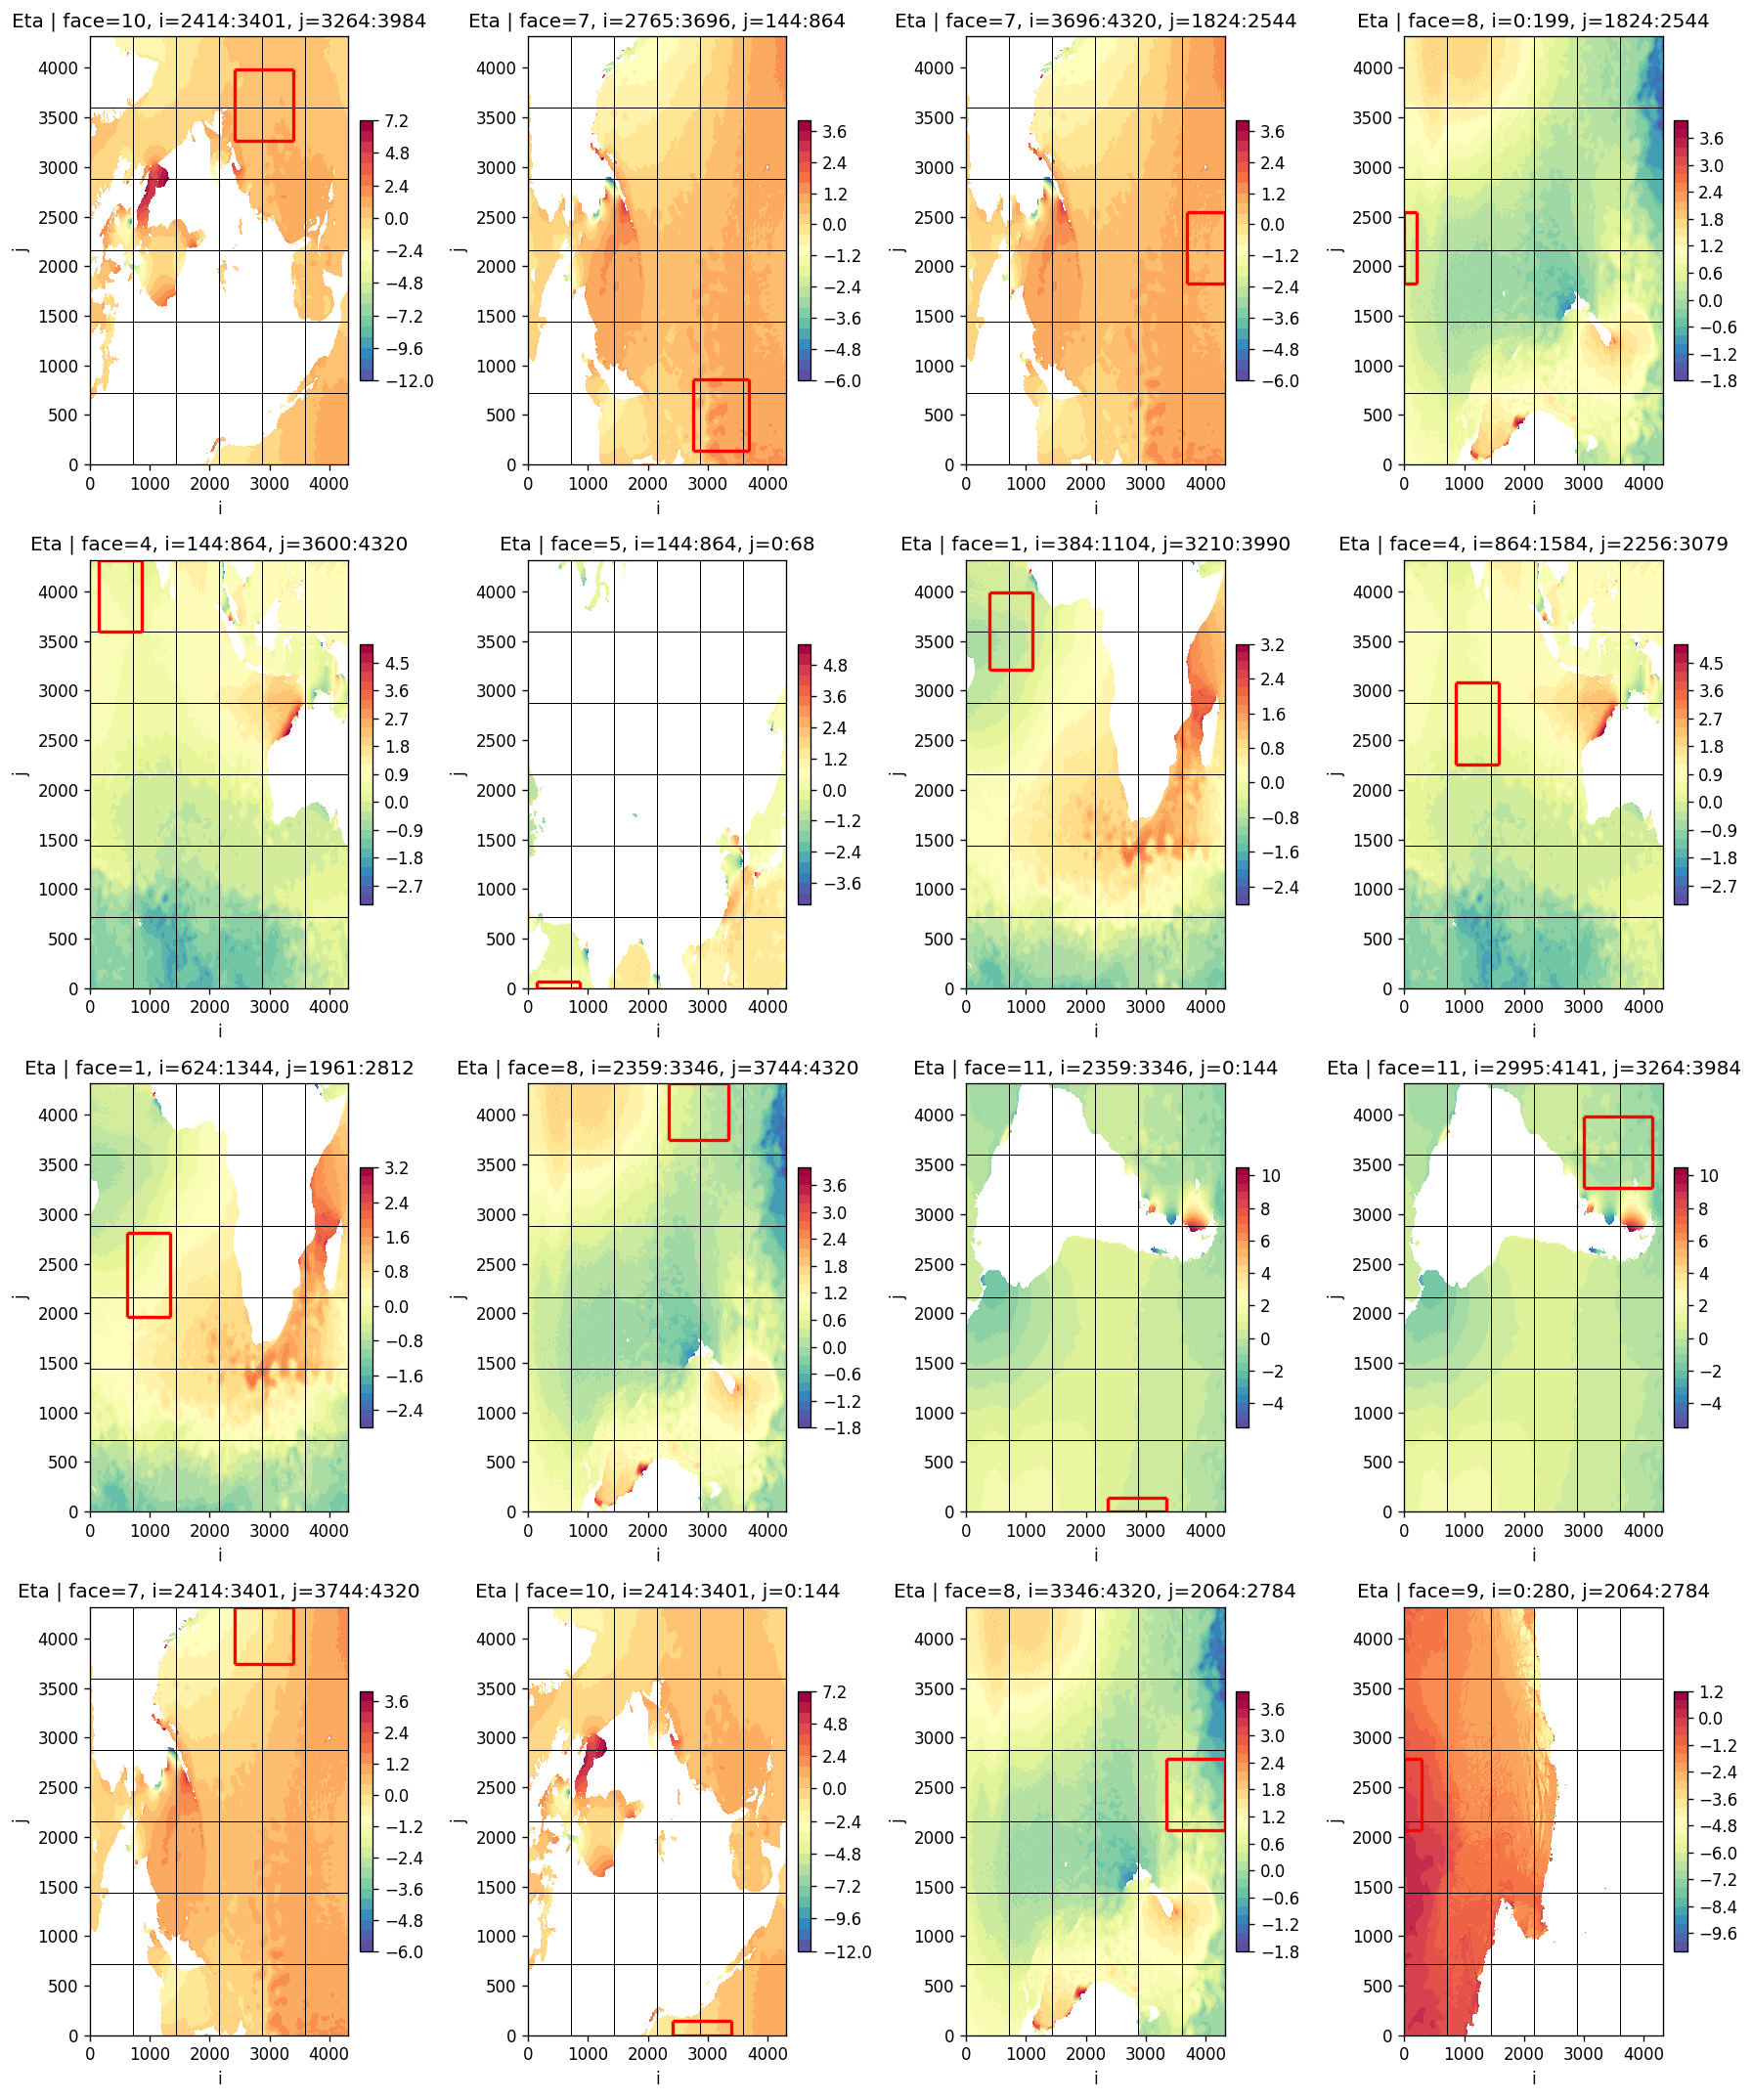

In [8]:
plot_var = "Eta"

fig, axes = plt.subplots(4, 4, figsize=(15, 18), dpi=120)
axes = axes.ravel()

for n in range(len(faces)):
    ax = axes[n]

    llc_sub = llc[plot_var].isel(face=faces[n])

    vmin = float(llc_sub.min().compute())
    vmax = float(llc_sub.max().compute())

    cf = ax.contourf(
        llc_sub["i"],
        llc_sub["j"],
        llc_sub,
        cmap="Spectral_r",
        vmin=vmin,
        vmax=vmax,
        levels=30
    )

    grid_vals = np.arange(0, 4320 + 720, 720)
    for g in grid_vals:
        ax.axhline(g, color="k", linewidth=0.6)
        ax.axvline(g, color="k", linewidth=0.6)

    ax.hlines(y=j_0[n], xmin=i_0[n], xmax=i_1[n], colors="r", linewidth=2.0)
    ax.hlines(y=j_1[n], xmin=i_0[n], xmax=i_1[n], colors="r", linewidth=2.0)
    ax.vlines(x=i_0[n], ymin=j_0[n], ymax=j_1[n], colors="r", linewidth=2.0)
    ax.vlines(x=i_1[n], ymin=j_0[n], ymax=j_1[n], colors="r", linewidth=2.0)

    ax.set_title(f"{plot_var} | face={faces[n]}, i={i_0[n]}:{i_1[n]}, j={j_0[n]}:{j_1[n]}")
    ax.set_xlim(0, 4320)
    ax.set_ylim(0, 4320)
    ax.set_xlabel("i")
    ax.set_ylabel("j")

    plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(faces):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
faces = [1, 10, 7, 7, 4, 1, 4, 1, 8, 11, 7, 8]
i_0 = [2880, 2160, 2880, 3600, 0, 720, 720, 720, 2160, 2880, 2880, 3600]
i_1 = [3600, 2880, 3600, 4320, 720, 1440, 1440, 1440, 2880, 3600, 3600, 4320]
j_0 = [720, 2880, 0, 1440, 3600, 2880, 2160, 1440, 3600, 3600, 3600, 2160]
j_1 = [1440, 3600, 720, 2160, 4320, 3600, 2880, 2160, 4320, 4320, 4320, 2880]

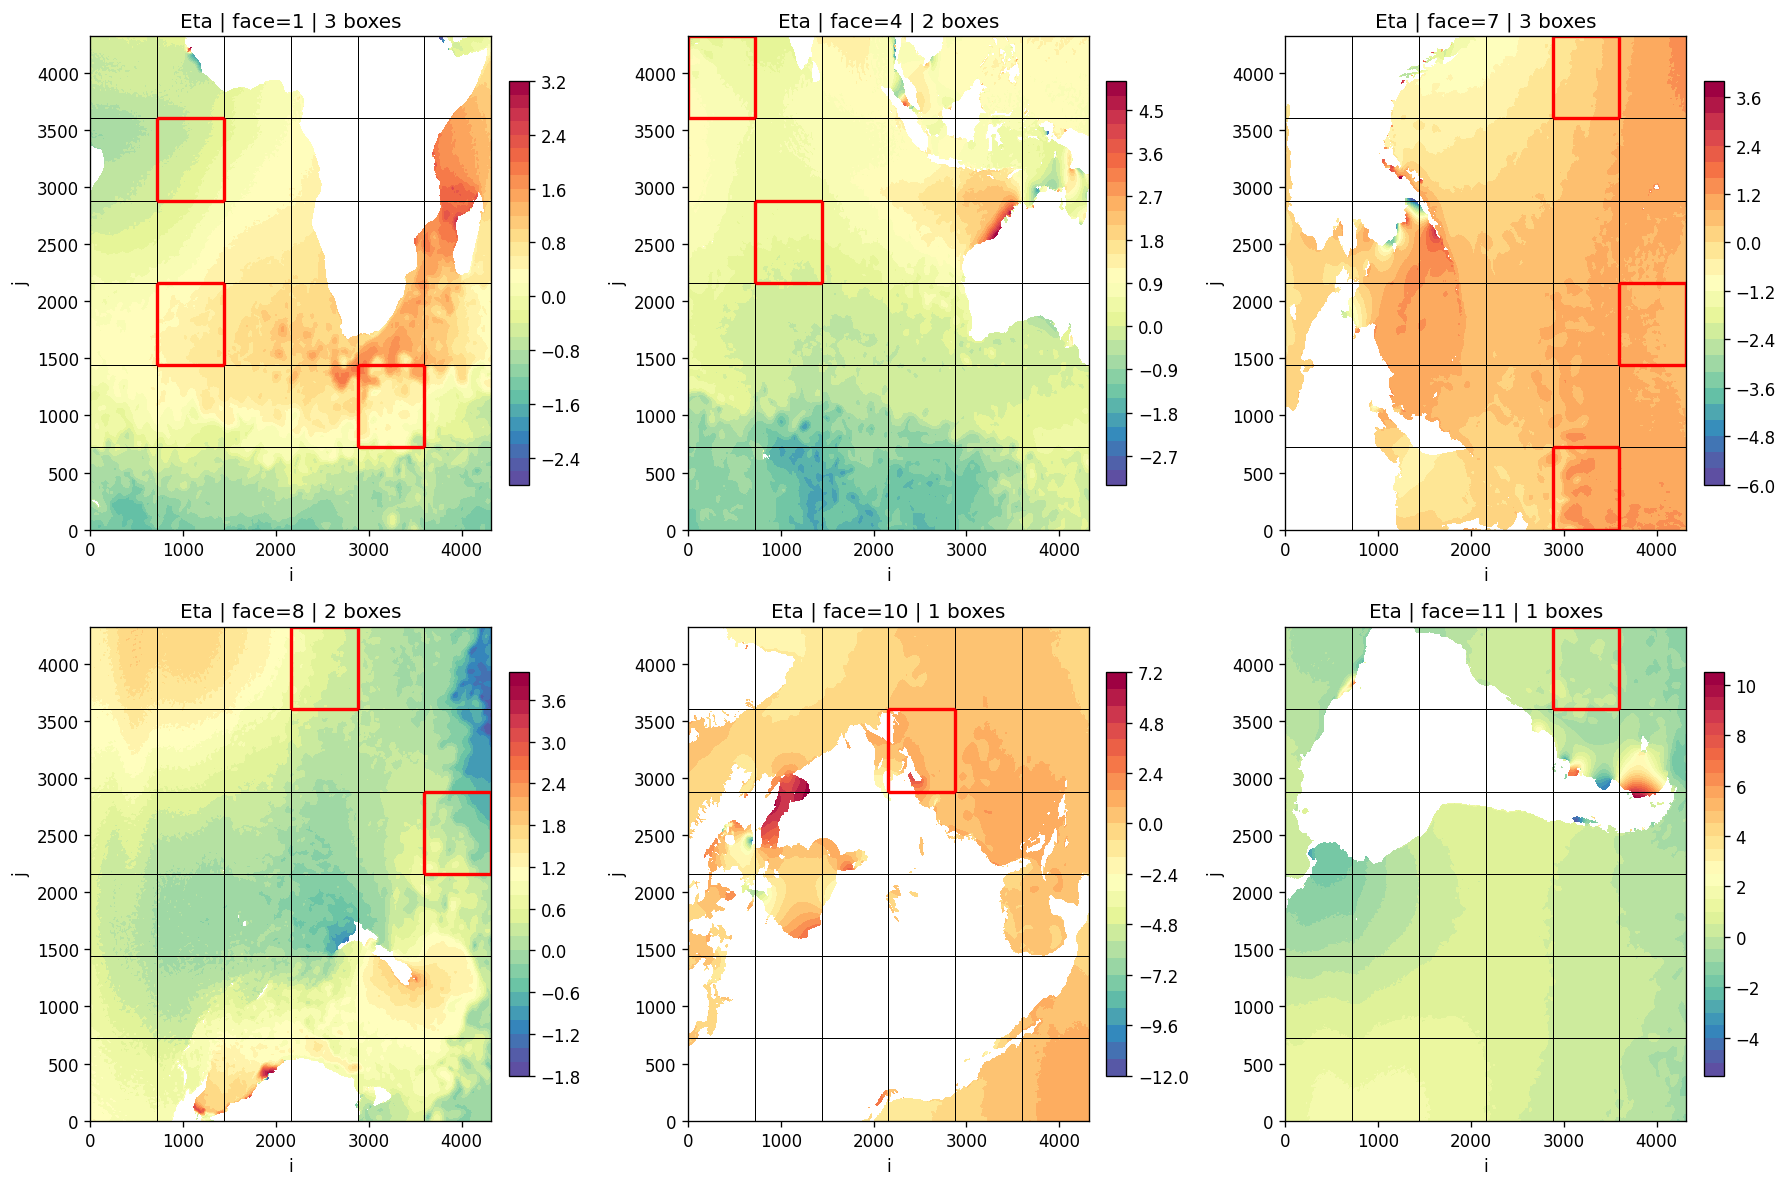

In [20]:
from collections import defaultdict

plot_var = "Eta"

face_to_boxes = defaultdict(list)
for n, face in enumerate(faces):
    face_to_boxes[face].append((i_0[n], i_1[n], j_0[n], j_1[n]))

unique_faces = sorted(face_to_boxes.keys())

fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=120)
axes = axes.ravel()

grid_vals = np.arange(0, 4320 + 720, 720)

for ax, face in zip(axes, unique_faces):
    llc_sub = llc[plot_var].isel(face=face)

    vmin = float(llc_sub.min().compute())
    vmax = float(llc_sub.max().compute())

    cf = ax.contourf(
        llc_sub["i"],
        llc_sub["j"],
        llc_sub,
        cmap="Spectral_r",
        vmin=vmin,
        vmax=vmax,
        levels=30
    )

    for g in grid_vals:
        ax.axhline(g, color="k", linewidth=0.6)
        ax.axvline(g, color="k", linewidth=0.6)

    for i0, i1, j0, j1 in face_to_boxes[face]:
        ax.hlines(y=j0, xmin=i0, xmax=i1, colors="r", linewidth=2.0)
        ax.hlines(y=j1, xmin=i0, xmax=i1, colors="r", linewidth=2.0)
        ax.vlines(x=i0, ymin=j0, ymax=j1, colors="r", linewidth=2.0)
        ax.vlines(x=i1, ymin=j0, ymax=j1, colors="r", linewidth=2.0)

    ax.set_title(f"{plot_var} | face={face} | {len(face_to_boxes[face])} boxes")
    ax.set_xlim(0, 4320)
    ax.set_ylim(0, 4320)
    ax.set_xlabel("i")
    ax.set_ylabel("j")

    plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(unique_faces):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

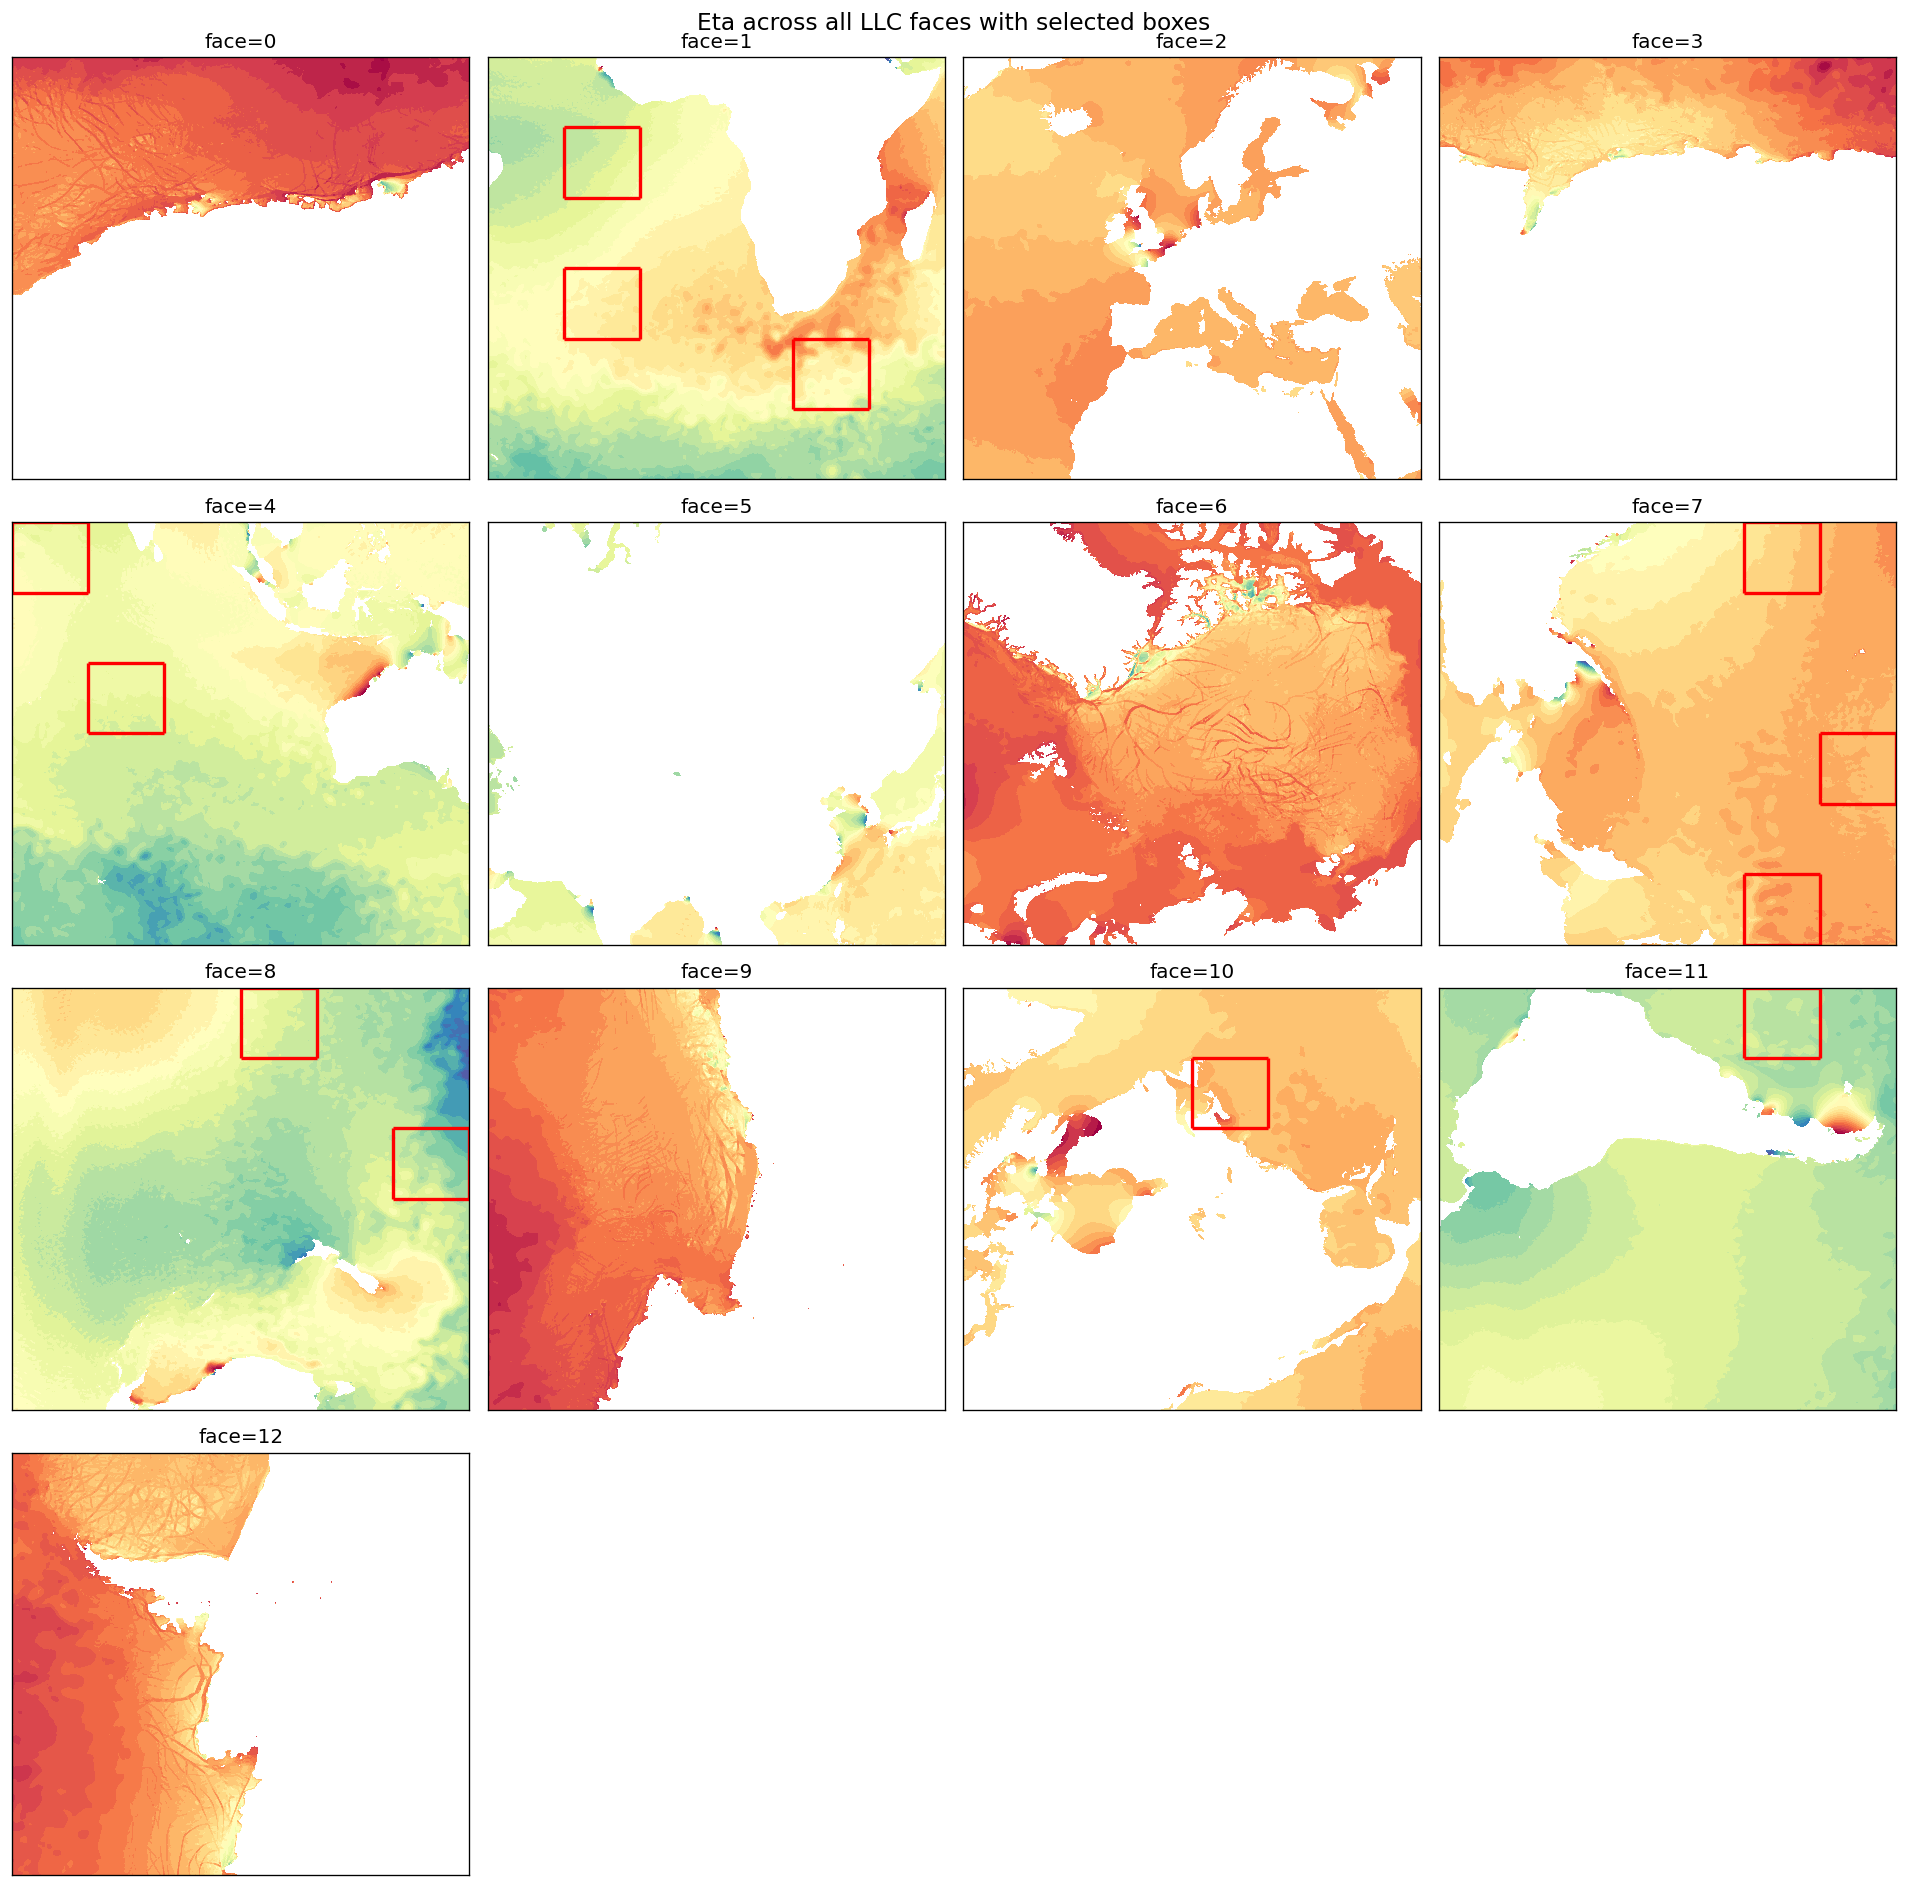

In [22]:
plot_var = "Eta"

fig, axes = plt.subplots(4, 4, figsize=(16, 16), dpi=120)
axes = axes.ravel()

for face in range(13):
    ax = axes[face]

    llc_sub = llc[plot_var].isel(face=face)

    vmin = float(llc_sub.min().compute())
    vmax = float(llc_sub.max().compute())

    cf = ax.contourf(
        llc_sub["i"],
        llc_sub["j"],
        llc_sub,
        cmap="Spectral_r",
        vmin=vmin,
        vmax=vmax,
        levels=30
    )

    # Overlay only boxes belonging to this face
    for n in range(len(faces)):
        if faces[n] != face:
            continue

        ax.hlines([j_0[n], j_1[n]], xmin=i_0[n], xmax=i_1[n], colors="r", linewidth=2.0)
        ax.vlines([i_0[n], i_1[n]], ymin=j_0[n], ymax=j_1[n], colors="r", linewidth=2.0)

    ax.set_title(f"face={face}")
    ax.set_xlim(0, 4320)
    ax.set_ylim(0, 4320)
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[13:]:
    ax.axis("off")

fig.suptitle(f"{plot_var} across all LLC faces with selected boxes", fontsize=14)
plt.tight_layout()
plt.show()

In [27]:
llc

<xarray.Dataset> Size: 3GB
Dimensions:  (face: 13, j: 4320, i: 4320)
Coordinates:
  * face     (face) int16 26B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int16 9kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * i        (i) int16 9kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
    k        int16 2B 0
    time     datetime64[ns] 8B 2011-09-13
Data variables:
    Eta      (face, j, i) float32 970MB dask.array<chunksize=(13, 4320, 4320), meta=np.ndarray>
    XC       (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    YC       (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>

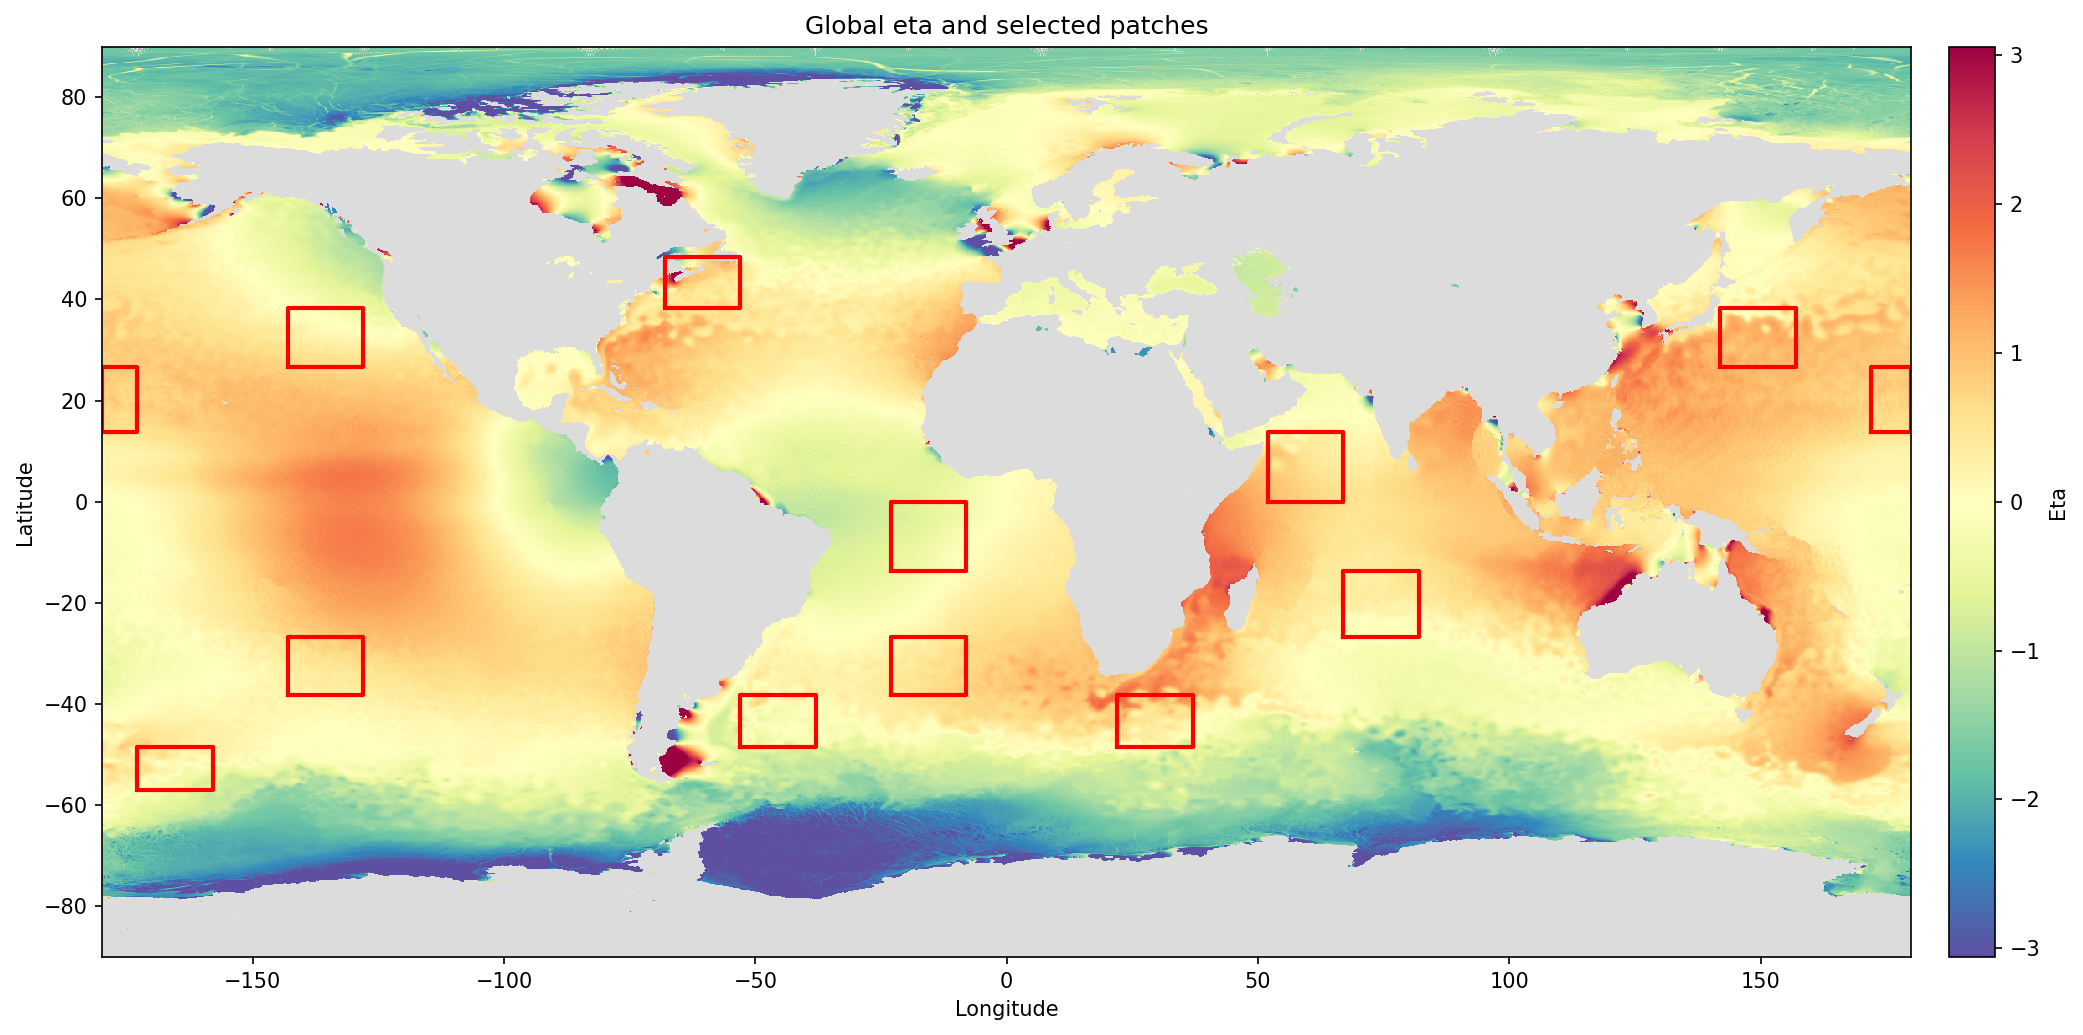

In [30]:
plot_var = "Eta"

# ---- Load and clean field ----
raw = llc[plot_var].compute().values          # (13, 4320, 4320)
xc  = llc["XC"].compute().values
yc  = llc["YC"].compute().values

# Treat exact zeros (LLC land) and non-finite as missing
valid = np.isfinite(raw) & (raw != 0.0) & np.isfinite(xc) & np.isfinite(yc)

x = xc[valid].ravel()
y = yc[valid].ravel()
v = raw[valid].ravel()

# Wrap longitudes safely into [-180, 180)
x = ((x + 180.0) % 360.0) - 180.0

# ---- Bin onto a regular lon/lat grid ----
nlon, nlat = 2160, 1080                       # ~1/6 deg; bump up if you want more detail
lon_edges = np.linspace(-180.0, 180.0, nlon + 1)
lat_edges = np.linspace(-90.0,  90.0,  nlat + 1)

sums,   _, _ = np.histogram2d(x, y, bins=[lon_edges, lat_edges], weights=v)
counts, _, _ = np.histogram2d(x, y, bins=[lon_edges, lat_edges])

with np.errstate(invalid="ignore", divide="ignore"):
    grid = np.where(counts > 0, sums / counts, np.nan).T   # shape (nlat, nlon)

# ---- Color scaling ----
vlim = float(np.nanpercentile(np.abs(grid), 98))
norm = colors.TwoSlopeNorm(vmin=-vlim, vcenter=0.0, vmax=vlim)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
ax.set_facecolor("gainsboro")

cf = ax.pcolormesh(
    lon_edges, lat_edges, grid,
    cmap="Spectral_r",
    norm=norm,
    shading="flat",
    rasterized=True,
)

# ---- Box helpers ----
def plot_box(ax, lon_min, lon_max, lat_min, lat_max, **kwargs):
    ax.plot(
        [lon_min, lon_max, lon_max, lon_min, lon_min],
        [lat_min, lat_min, lat_max, lat_max, lat_min],
        **kwargs,
    )


def plot_box_dateline_safe(ax, lon_vals, lat_vals, **kwargs):
    lon_vals = np.asarray(lon_vals)
    lat_vals = np.asarray(lat_vals)
    lon_vals = lon_vals[np.isfinite(lon_vals)]
    lat_vals = lat_vals[np.isfinite(lat_vals)]

    lat_min = float(lat_vals.min())
    lat_max = float(lat_vals.max())

    # Wrap into [-180, 180)
    lon_wrapped = ((lon_vals + 180.0) % 360.0) - 180.0

    # And also into [0, 360) to detect compact wrapped intervals
    lon_360 = (lon_vals + 360.0) % 360.0

    raw_min = float(lon_wrapped.min())
    raw_max = float(lon_wrapped.max())
    raw_span = raw_max - raw_min

    span_360 = float(lon_360.max() - lon_360.min())

    if raw_span <= 180:
        plot_box(ax, raw_min, raw_max, lat_min, lat_max, **kwargs)
    elif span_360 <= 180:
        # Box crosses the dateline; split it
        lon_min = ((float(lon_360.min()) + 180.0) % 360.0) - 180.0
        lon_max = ((float(lon_360.max()) + 180.0) % 360.0) - 180.0
        if lon_min <= lon_max:
            plot_box(ax, lon_min, lon_max, lat_min, lat_max, **kwargs)
        else:
            plot_box(ax, lon_min, 180.0, lat_min, lat_max, **kwargs)
            plot_box(ax, -180.0, lon_max, lat_min, lat_max, **kwargs)
    else:
        # Pathological case (e.g. wraps around pole); skip
        pass


# ---- Draw selected patches ----
for n in range(len(faces)):
    face = faces[n]

    xc_box = llc["XC"].isel(
        face=face,
        j=slice(j_0[n], j_1[n]),
        i=slice(i_0[n], i_1[n]),
    ).compute().values

    yc_box = llc["YC"].isel(
        face=face,
        j=slice(j_0[n], j_1[n]),
        i=slice(i_0[n], i_1[n]),
    ).compute().values

    plot_box_dateline_safe(
        ax,
        xc_box.ravel(),
        yc_box.ravel(),
        color="red",
        linewidth=2.0,
    )

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global eta and selected patches")

fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02, label=plot_var)

plt.tight_layout()
plt.show()